<a href="https://colab.research.google.com/github/artmakar2/project/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [16]:
def generate_data():
    """Создает тестовые данные с 5 признаками"""
    np.random.seed(50)

    # Три кластера в 5-мерном пространстве
    n_points = 50  # точек в каждом кластере

    cluster1 = np.random.randn(n_points, 5) * 3
    cluster2 = np.random.randn(n_points, 5) * 0.63
    cluster3 = np.random.randn(n_points, 5) / 1.5

    # Объединяем все кластеры
    X = np.vstack([cluster1, cluster2, cluster3])

    # Создаем DataFrame с понятными названиями колонок
    columns = ['Признак_1', 'Признак_2', 'Признак_3', 'Признак_4', 'Признак_5']
    df = pd.DataFrame(X, columns=columns)

    # Добавляем небольшую информацию о данных
    print(f"Сгенерировано данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
    print("\nСтатистика по каждому признаку:")
    print(df.describe().round(2))

    # Показываем первые несколько строк
    print("\nПервые 5 строк данных:")
    print(df.head())

    return df

def load_data():
    """Загружает данные (тестовые или из файла)"""
    choice = input("1 - тестовые данные, 2 - загрузить файл: ")

    if choice == '1':
        return generate_data()
    elif choice == '2':
        filename = input("Имя файла (csv): ")
        try:
            return pd.read_csv(filename)
        except:
            print("Ошибка загрузки, использую тестовые данные")
            return generate_data()
    else:
        return generate_data()

def prepare_data(df):
    """Подготавливает данные для кластеризации"""
    # Удаляем пропуски
    df = df.dropna()

    # Нормализуем данные
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)

    print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")
    return X_scaled, df

def find_best_k(X, max_k=10):
    """Находит оптимальное количество кластеров методом локтя"""

    # Проверка данных
    if len(X) < 2:
        print("Недостаточно данных")
        return 2

    max_k = min(max_k, len(X) - 1)
    inertia = []

    # Расчет инерции для разных K
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)
        print(f"K={k}: {kmeans.inertia_:.0f}")

    # Простой график
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, max_k + 1), inertia, 'bo-', linewidth=2)
    plt.xlabel('K')
    plt.ylabel('Инерция')
    plt.title('Метод локтя')
    plt.grid(True)
    plt.show()

    # Автоматический выбор K по максимальному изгибу
    if len(inertia) >= 3:
        diffs = [inertia[i-1] - inertia[i] for i in range(1, len(inertia))]
        best_k = diffs.index(max(diffs)) + 2
        print(f"Рекомендуется K={best_k}")

        k = input(f"Выберите K: ")
        return int(k) if k.strip() else best_k

    return 2

def cluster_data(X, n_clusters):
    """Выполняет кластеризацию"""
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    return labels, kmeans.cluster_centers_

def visualize_clusters(X, labels, centers):
    """Визуализирует результаты"""
    # Уменьшаем размерность для визуализации
    if X.shape[1] > 2:
        pca = PCA(n_components=2)
        X_plot = pca.fit_transform(X)
        centers_plot = pca.transform(centers)
    else:
        X_plot = X
        centers_plot = centers

    plt.figure(figsize=(10, 6))

    # Рисуем точки
    scatter = plt.scatter(X_plot[:, 0], X_plot[:, 1],
                         c=labels, cmap='viridis', s=50)

    # Рисуем центры
    plt.scatter(centers_plot[:, 0], centers_plot[:, 1],
               c='red', marker='X', s=200, edgecolors='black')

    plt.colorbar(scatter, label='Кластер')
    plt.title('Результаты кластеризации')
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.grid(True, alpha=0.3)
    plt.show()

def show_statistics(df, labels):
    """Показывает статистику по кластерам"""
    df['Cluster'] = labels

    print("\n=== СТАТИСТИКА ПО КЛАСТЕРАМ ===")
    for cluster in sorted(df['Cluster'].unique()):
        cluster_data = df[df['Cluster'] == cluster]
        print(f"\nКластер {cluster}: {len(cluster_data)} объектов")
        print(cluster_data.describe().loc[['mean', 'std']].round(2))

def save_results(df, filename='clusters.csv'):
    """Сохраняет результаты"""
    df.to_csv(filename, index=False)
    print(f"Результаты сохранены в {filename}")

def main():
    """Главная функция"""
    print("=" * 40)
    print("ПРОГРАММА КЛАСТЕРНОГО АНАЛИЗА")
    print("=" * 40)

1 - тестовые данные, 2 - загрузить файл: 1
Сгенерировано данных: 150 строк, 5 столбцов

Статистика по каждому признаку:
       Признак_1  Признак_2  Признак_3  Признак_4  Признак_5
count     150.00     150.00     150.00     150.00     150.00
mean        0.11      -0.03       0.04      -0.14      -0.35
std         1.73       1.91       1.85       2.03       1.73
min        -6.06      -7.12      -5.63     -11.43      -7.71
25%        -0.54      -0.68      -0.56      -0.63      -0.75
50%         0.14      -0.09      -0.04       0.05      -0.22
75%         0.55       0.43       0.65       0.62       0.36
max         7.39       9.94       8.12       8.14       4.56

Первые 5 строк данных:
   Признак_1  Признак_2  Признак_3  Признак_4  Признак_5
0  -4.681056  -0.092933  -1.862785  -4.393741   4.235838
1  -1.430196  -2.341408   3.210803  -3.846878  -3.982437
2   0.379013   2.586581   2.090211  -1.003696  -2.992578
3   4.796725   9.942226   2.963311   0.371599   2.228356
4  -1.181868   0.44434

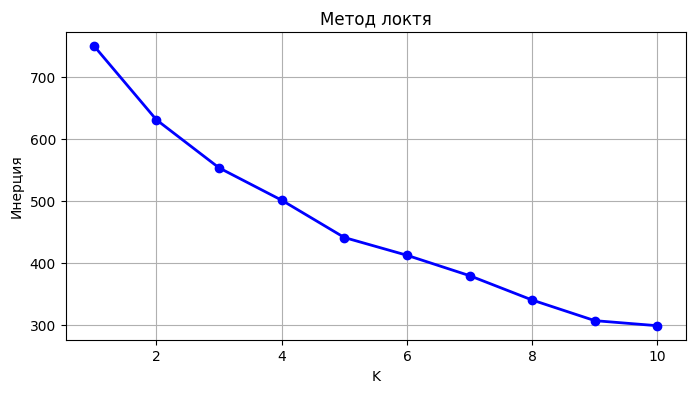

Рекомендуется K=2
Выберите K: 2


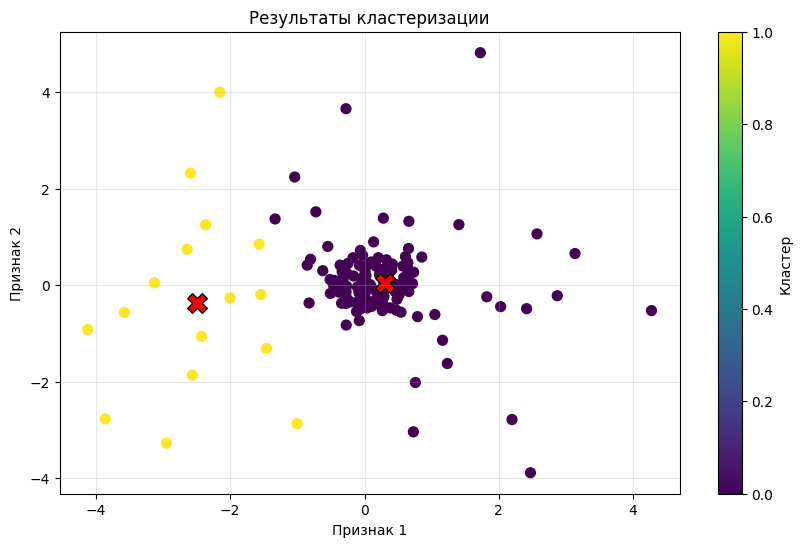


=== СТАТИСТИКА ПО КЛАСТЕРАМ ===

Кластер 0: 134 объектов
      Признак_1  Признак_2  Признак_3  Признак_4  Признак_5  Cluster
mean      -0.09       0.16       0.25       0.09       0.01      0.0
std        1.46       1.71       1.53       1.68       1.26      0.0

Кластер 1: 16 объектов
      Признак_1  Признак_2  Признак_3  Признак_4  Признак_5  Cluster
mean       1.82      -1.68      -1.67       -2.1      -3.40      1.0
std        2.72       2.64       3.13        3.4       2.14      0.0
Сохранить результаты? (д/н): н
ПРОГРАММА КЛАСТЕРНОГО АНАЛИЗА


In [17]:
# 1. Загрузка данных
df = load_data()

# 2. Подготовка данных
X_scaled, df_original = prepare_data(df)

# 3. Поиск оптимального K
n_clusters = find_best_k(X_scaled)

# 4. Кластеризация
labels, centers = cluster_data(X_scaled, n_clusters)

# 5. Визуализация
visualize_clusters(X_scaled, labels, centers)

# 6. Статистика
show_statistics(df_original, labels)

# 7. Сохранение
save_choice = input("Сохранить результаты? (д/н): ")
if save_choice.lower() == 'д':
     save_results(pd.concat([df_original, pd.Series(labels, name='Cluster')], axis=1))

if __name__ == "__main__":
    main()